In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fastnc import bispectrum
import os
from astropy.cosmology import wCDM

## Baryonic effect on power spectrum
For the 3pt project, we try to avoid the baryon effect by setting scale cut.
The scale cut is determined so that the resultant cosmological parameter is unbiasly recovered.
We use OWLS-AGN-like model to create baryon contaminated data vector. However, there is no theoretical code to simulate that, so we do it by rescale the TNG-300 baryon effect on bispectrum by a factor. 
Where the rescaling factor is obtained by comparing the baryon suppression factors in power spectrum level in OWLS-AGN and TNG-300.

In [3]:
import sys
sys.path.append('../../cosmosis-standard-library/structure/baryon_power_scaling/')
import baryonic

ModuleNotFoundError: No module named 'baryonic'

In [4]:
r = baryonic.RatioDatPowerModulator('../../cosmosis-standard-library/structure/baryon_power_scaling/data/logPkRatio_owls_AGN.dat')

NameError: name 'baryonic' is not defined

In [5]:
k = np.logspace(-1, 2, 100)
z = np.linspace(0, 1, 10)
p = np.ones((k.size, z.size))
pb= r.modulate(k,z,p)

NameError: name 'r' is not defined

In [ ]:
plt.xscale('log')
plt.plot(k, pb)
plt.show()

## Baryonic effect on bispectrum

In [6]:
bs = bispectrum.BispectrumHalofit()

In [7]:
cosmo = bispectrum.wPlanck18
dirname_fastnc = '../data/devl/'
k, pklin = np.loadtxt(os.path.join(dirname_fastnc, 'pklin_P18.dat'), unpack=True)
z, lgr = np.loadtxt(os.path.join(dirname_fastnc, 'lgr_P18.dat'), unpack=True)

In [8]:
bs.set_cosmology(cosmo)
bs.set_pklin(k, pklin)
bs.set_lgr(z, lgr)

In [6]:
k = k1 = k2 = k3 = np.logspace(-1, 2, 200)
z = np.ones_like(k1) * 1.0

bs.set_baryon_param({'fb':0.0})
bk_dm = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.0})
bk_tng300 = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.5**1.5})
bk_owls = bs.matter_bispectrum(k1, k2, k3, z)

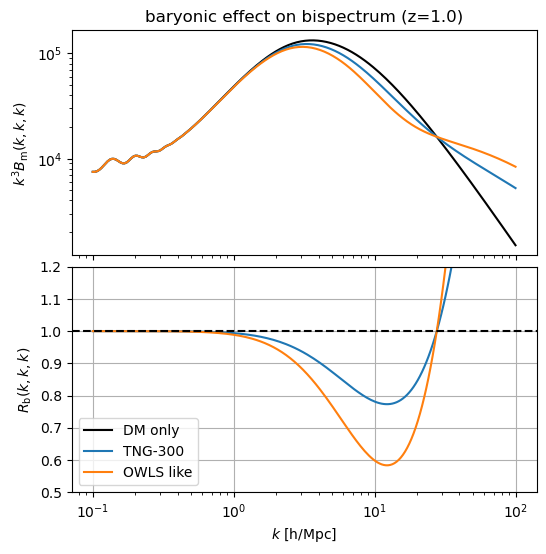

In [7]:
fig, axes = plt.subplots(2,1, figsize=(6, 6), sharex=True)
plt.subplots_adjust(hspace=0.05)
axes[0].set_title('baryonic effect on bispectrum (z={})'.format(z[0]))
axes[0].loglog(k, k**3*bk_dm, 'k')
axes[0].loglog(k, k**3*bk_tng300)
axes[0].loglog(k, k**3*bk_owls)
axes[0].set_ylabel(r'$k^3B_{\rm m}(k,k,k)$')
axes[1].semilogx(np.nan, color='k', label='DM only')
axes[1].semilogx(k, bk_tng300/bk_dm, label='TNG-300')
axes[1].semilogx(k, bk_owls/bk_dm, label='OWLS like')
axes[1].axhline(1.0, color='k', ls='--')
axes[1].set_ylim(0.5, 1.2)
axes[1].legend()
axes[1].set_ylabel(r'$R_{\rm b}(k,k,k)$')
axes[1].set_xlabel(r'$k$ [h/Mpc]')
axes[1].grid()
plt.show()

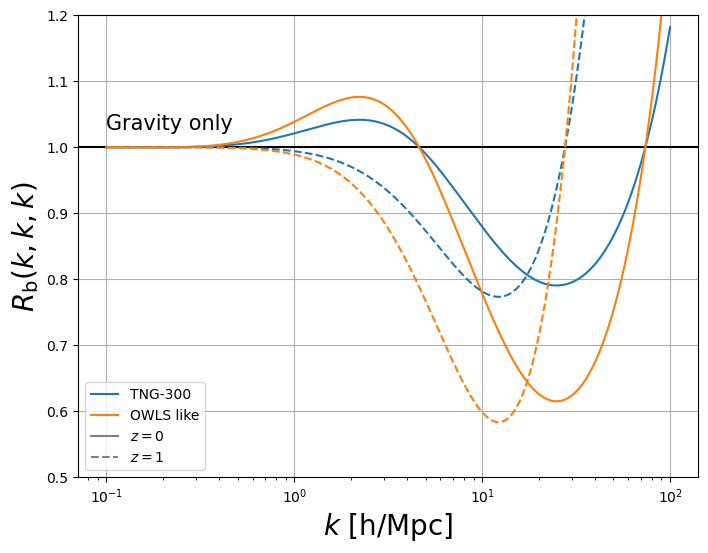

In [13]:
fig, ax = plt.subplots(1,1, figsize=(8, 6), sharex=True)
ax.axhline(1.0, color='k', ls='-')

for i, _z in enumerate([0, 1.0]):
    ls = ['-', '--'][i]
    z = np.ones_like(k1) * _z
    bs.set_baryon_param({'fb':0.0})
    bk_dm = bs.matter_bispectrum(k1, k2, k3, z)
    bs.set_baryon_param({'fb':1.0})
    bk_tng300 = bs.matter_bispectrum(k1, k2, k3, z)
    bs.set_baryon_param({'fb':1.5**1.5})
    bk_owls = bs.matter_bispectrum(k1, k2, k3, z)
    ax.semilogx(k, bk_tng300/bk_dm, ls=ls, color='C0')
    ax.semilogx(k, bk_owls/bk_dm, ls=ls, color='C1')

# dummy plot for legend
ax.text(1e-1, 1.02, 'Gravity only', transform=ax.transData, ha='left', va='bottom', color='k', fontsize=15)
ax.plot(np.nan, color='C0', label='TNG-300')
ax.plot(np.nan, color='C1', label='OWLS like')
ax.plot(np.nan, color='gray', label=r'$z=0$')
ax.plot(np.nan, color='gray', ls='--', label=r'$z=1$')

# 
ax.set_ylim(0.5, 1.2)
ax.legend(loc='lower left', bbox_to_anchor=(0.0, 0.0))
ax.set_ylabel(r'$R_{\rm b}(k,k,k)$', fontsize=20)
ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=20)
ax.grid()
#fig.savefig('../plots/bispectrum_baryon_effect.pdf', bbox_inches='tight')
plt.show()

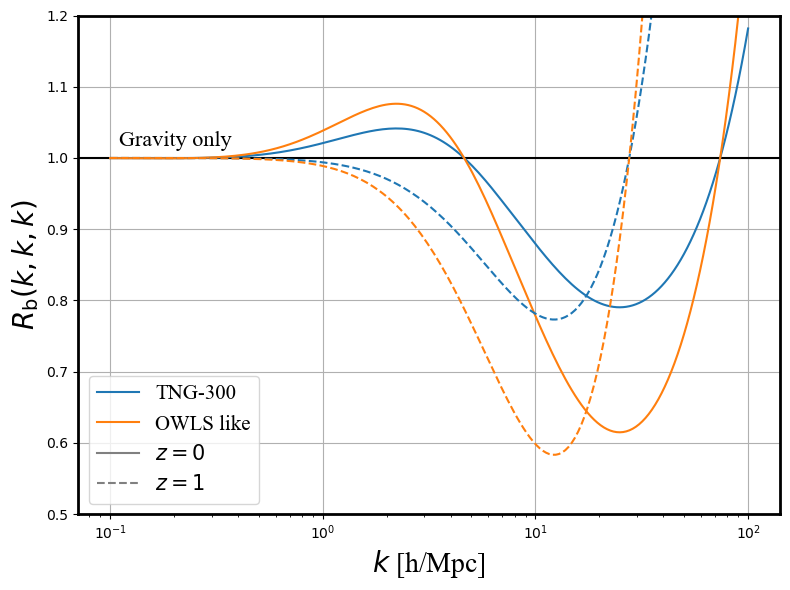

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

# Horizontal line
ax.axhline(1.0, color='k', ls='-')

# Plotting data
for i, _z in enumerate([0, 1.0]):
    ls = ['-', '--'][i]
    z = np.ones_like(k1) * _z
    bs.set_baryon_param({'fb': 0.0})
    bk_dm = bs.matter_bispectrum(k1, k2, k3, z)
    bs.set_baryon_param({'fb': 1.0})
    bk_tng300 = bs.matter_bispectrum(k1, k2, k3, z)
    bs.set_baryon_param({'fb': 1.5**1.5})
    bk_owls = bs.matter_bispectrum(k1, k2, k3, z)
    ax.semilogx(k, bk_tng300 / bk_dm, ls=ls, color='C0')
    ax.semilogx(k, bk_owls / bk_dm, ls=ls, color='C1')

# Dummy plot for legend
ax.text(
    1.1e-1, 1.01, 'Gravity only', transform=ax.transData,
    ha='left', va='bottom', color='k', fontsize=16, fontname='Times New Roman', fontweight='normal'
)
ax.plot(np.nan, color='C0', label='TNG-300')
ax.plot(np.nan, color='C1', label='OWLS like')
ax.plot(np.nan, color='gray', label=r'$z=0$')
ax.plot(np.nan, color='gray', ls='--', label=r'$z=1$')

# Axes limits and labels
ax.set_ylim(0.5, 1.2)
ax.set_ylabel(r'$R_{\rm b}(k,k,k)$', fontsize=20, fontname='Times New Roman', fontweight='normal')
ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=20, fontname='Times New Roman', fontweight='normal')

# Customize grid
ax.grid()

# Customize legend
ax.legend(
    loc='lower left', bbox_to_anchor=(0.0, 0.0),
    prop={'family': 'Times New Roman', 'size': 15, 'weight': 'normal'}
)

# Thicker borders
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Show plot
plt.tight_layout()
fig.savefig('bispectrum_baryon_effect_December2024.pdf', bbox_inches='tight')
#plt.show()

In [40]:
k = k1 = np.logspace(-1, 2, 200)
k2 = k3 = k1
z = np.ones_like(k1) * 1.0

bs.set_baryon_param({'fb':0.0})
bk_dm = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.0})
bk_tng300 = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.5**1.5})
bk_owls = bs.matter_bispectrum(k1, k2, k3, z)

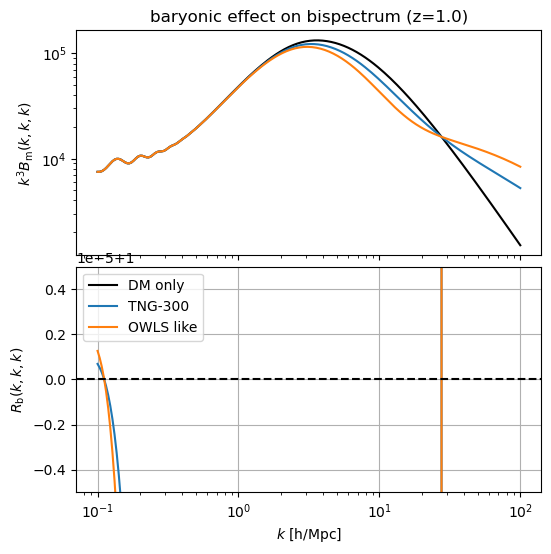

In [45]:
fig, axes = plt.subplots(2,1, figsize=(6, 6), sharex=True)
plt.subplots_adjust(hspace=0.05)
axes[0].set_title('baryonic effect on bispectrum (z={})'.format(z[0]))
axes[0].loglog(k, k**3*bk_dm, 'k')
axes[0].loglog(k, k**3*bk_tng300)
axes[0].loglog(k, k**3*bk_owls)
axes[0].set_ylabel(r'$k^3B_{\rm m}(k,k,k)$')
axes[1].semilogx(np.nan, color='k', label='DM only')
axes[1].semilogx(k, bk_tng300/bk_dm, label='TNG-300')
axes[1].semilogx(k, bk_owls/bk_dm, label='OWLS like')
axes[1].axhline(1.0, color='k', ls='--')
axes[1].set_ylim(0.999995, 1.000005)
axes[1].legend()
axes[1].set_ylabel(r'$R_{\rm b}(k,k,k)$')
axes[1].set_xlabel(r'$k$ [h/Mpc]')
axes[1].grid()
plt.show()

In [64]:
import numpy as np
from astropy.cosmology import Planck18 as cosmo  # Replace with your preferred cosmology

def calculate_theta(k_max, z_values):
    """
    Calculate the angular scale theta (in arcminutes) for a given k_max at different redshifts.
    
    Parameters:
        k_max (float): Maximum k in units of h/Mpc.
        z_values (list or array): Redshift values to calculate theta.
        
    Returns:
        list: Angular scale theta in arcminutes for each redshift.
    """
    c = 3e5  # Speed of light in km/s
    thetas = []
    
    for z in z_values:
        # Comoving distance in Mpc
        chi = cosmo.comoving_distance(z).value  # Returns comoving distance in Mpc
        # Angular scale in radians
        theta_rad = np.pi / (k_max * chi)
        # Convert to arcminutes
        theta_arcmin = np.degrees(theta_rad) * 60
        thetas.append(theta_arcmin)
    
    return thetas

# Define parameters
k_max = 4  # in h/Mpc
z_values = [0.1, 0.5, 1.0, 2.0]  # Example redshift values

# Calculate and print results
thetas = calculate_theta(k_max, z_values)
for z, theta in zip(z_values, thetas):
    print(f"Redshift z = {z:.1f}: θ = {theta:.2f} arcminutes")


Redshift z = 0.1: θ = 6.24 arcminutes
Redshift z = 0.5: θ = 1.39 arcminutes
Redshift z = 1.0: θ = 0.80 arcminutes
Redshift z = 2.0: θ = 0.51 arcminutes


In [68]:
import numpy as np
from astropy.cosmology import Planck18 as cosmo  # Replace with your preferred cosmology

def calculate_k(theta_arcmin, z_values):
    """
    Calculate the comoving wavenumber k (in h/Mpc) for a given angular scale theta (arcminutes) at different redshifts.
    
    Parameters:
        theta_arcmin (float): Angular scale in arcminutes.
        z_values (list or array): Redshift values to calculate k.
        
    Returns:
        list: Comoving wavenumber k in h/Mpc for each redshift.
    """
    c = 3e5  # Speed of light in km/s
    theta_rad = np.radians(theta_arcmin / 60)  # Convert arcminutes to radians
    ks = []
    
    for z in z_values:
        # Comoving distance in Mpc
        chi = cosmo.comoving_distance(z).value  # Returns comoving distance in Mpc
        # Comoving wavenumber
        k = np.pi / (chi * theta_rad)
        ks.append(k)
    
    return ks

# Define parameters
theta_arcmin = 3  # Example input in arcminutes
z_values = [0.1, 0.5, 1.0, 2.0]  # Example redshift values

# Calculate and print results
ks = calculate_k(theta_arcmin, z_values)
for z, k in zip(z_values, ks):
    print(f"Redshift z = {z:.1f}: k = {k:.2f} h/Mpc")


Redshift z = 0.1: k = 8.32 h/Mpc
Redshift z = 0.5: k = 1.85 h/Mpc
Redshift z = 1.0: k = 1.06 h/Mpc
Redshift z = 2.0: k = 0.68 h/Mpc


In [56]:
import numpy as np
from astropy.cosmology import Planck18 as cosmo  # Replace with your preferred cosmology

def comoving_to_angular_scale(R, z):
    """
    Convert a comoving distance scale R (in Mpc) to an angular scale theta (in arcminutes) at redshift z.

    Parameters:
        R (float or np.ndarray): Comoving distance scale in Mpc.
        z (float): Redshift.

    Returns:
        theta (float or np.ndarray): Angular scale in arcminutes.
    """
    # Get the angular diameter distance in Mpc
    D_A = cosmo.angular_diameter_distance(z).value  # in Mpc

    # Convert R/D_A to radians, then to arcminutes
    theta_rad = R / D_A
    theta_arcmin = np.degrees(theta_rad) * 60  # Convert radians to arcminutes

    return theta_arcmin

# Example usage:
R_example = 1 # comoving scale in Mpc
z_example = 0.5   # redshift

theta_example = comoving_to_angular_scale(R_example, z_example)
print(f"Angular scale θ: {theta_example:.2f} arcminutes")

Angular scale θ: 2.65 arcminutes
